# 🏨 Детекция неполных описаний комнат для Т-Путешествия


> Предсказать, что в описании комнаты недостаточно данных для сопоставления с эталонным описанием комнаты, чтобы минимизировать поток заданий людям на ручную проверку.

## Задача
Создать ML-модель, которая предсказывает, что описание комнаты неполное (is_incomplete = 1), то есть:

- В нём недостаточно данных для автоматического споставления со списанием
- Его нужно отправить на ручную проверку людям

## Цель
Минимизировать поток заданий в краудсорсинг, автоматически отфильтровывая только действительно проблемные описания.

## Проблема
Отели размещают свои номера на разных платформах (Booking.com, TravelLine, Expedia), и описания одного и того же номера могут различаться — где-то указаны не все характеристики. Ожидания туристов неоправданы.

## Метрики
- **Precision (Точность)**: минимизация ложных срабатываний
- **Recall (Полнота)**: максимизация обнаружения неполных описаний
- **F1-score**: баланс между точностью и полнотой

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, roc_curve, auc, confusion_matrix, precision_recall_curve, precision_score, recall_score

import pickle

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 1. Загрузка и первичный анализ данных

In [2]:
df = pd.read_csv('hotel_rooms_data.csv')
print(f"Размер датасета: {df.shape}")
print(f"\nРаспределение целевой переменной:")
print(df['is_incomplete'].value_counts())
print(f"\nДоля неполных описаний: {df['is_incomplete'].mean()*100:.1f}%")
df.head()

Размер датасета: (10000, 15)

Распределение целевой переменной:
is_incomplete
0    6990
1    3010
Name: count, dtype: int64

Доля неполных описаний: 30.1%


,id,operator,room_class,area,bed_type,view,max_guests,amenities,description,floor,n_rooms,price,rating,n_photos,is_incomplete
0,0,Booking.com,Люкс,53.9,NaN,Вид на горы,NaN,"Мини-бар, Халаты, Телевизор, Балкон, Wi-Fi",слово слово слово слово слово слово слово слов...,NaN,3.0,2473.44,4.7,5,0
1,1,TravelLine,Люкс,54.8,NaN,NaN,3.0,Ванна,слово слово слово слово слово слово слово слов...,14.0,NaN,16222.88,5.0,8,1
2,2,Booking.com,Стандарт,19.2,Двуспальная кровать,Вид на город,1.0,Мини-бар,слово слово слово слово,NaN,NaN,17715.06,4.7,2,1
3,3,TravelLine,Стандарт,35.3,Две односпальные,NaN,2.0,"Фен, Ванна, Мини-бар, Душ, Сейф, Телевизор",слово слово слово слово слово слово слово слов...,10.0,2.0,22581.03,4.9,7,0
4,4,Expedia,Стандарт,69.9,NaN,Вид на бассейн,3.0,"Балкон, Сейф, Телевизор, Кондиционер, Душ, Wi-...",слово слово слово слово слово слово слово слов...,12.0,1.0,5241.26,3.6,6,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   operator       10000 non-null  object 
 2   room_class     9006 non-null   object 
 3   area           8538 non-null   float64
 4   bed_type       7026 non-null   object 
 5   view           7293 non-null   object 
 6   max_guests     8010 non-null   float64
 7   amenities      9005 non-null   object 
 8   description    9797 non-null   object 
 9   floor          7036 non-null   float64
 10  n_rooms        7514 non-null   float64
 11  price          10000 non-null  float64
 12  rating         8981 non-null   float64
 13  n_photos       10000 non-null  int64  
 14  is_incomplete  10000 non-null  int64  
dtypes: float64(6), int64(3), object(6)
memory usage: 1.1+ MB


## 2. Feature Engineering

Создаем признаки, которые помогут определить полноту описания:
- Количество пропущенных признаков (сколько столбцов содержит пропуски по данному наблюдению)
- Длина текстовых полей (ненулевое значение говорит о фактическом наличии признака)
- Бинарные признаки наличия данных (ключевых атрибутов)

После создания дополнитепльных числовых признаков заполним пропуски медианой для использования числовых значений как дополнительных признаков в модели. Модели сами определят важность признаков. Порой важно не соджержание признакак, а его наличие. Дополнительные признаки могут улучшить качество обучения.

In [4]:
def create_features(df):
    df = df.copy()
    
    # Количество пропущенных значений
    df['missing_count'] = df[['area', 'bed_type', 'view', 'max_guests', 'floor', 'n_rooms', 'rating']].isna().sum(axis=1)
    
    # 1) Длина текстовых полей
    df['room_class_len'] = df['room_class'].fillna('').str.strip().str.len()
    df['description_len'] = df['description'].fillna('').str.strip().str.len()
    df['amenities_count'] = df['amenities'].fillna('').str.split(',').str.len()

    
    # 2) Бинарные признаки наличия данных
    df['has_n_rooms'] = df['n_rooms'].notna().astype(int)
    df['has_rating'] = df['rating'].notna().astype(int)
    df['has_area'] = df['area'].notna().astype(int)
    df['has_max_guests'] = df['max_guests'].notna().astype(int)
    df['has_floor'] = df['floor'].notna().astype(int)

    df['has_bed_type'] = (df['bed_type'].fillna('') != '').astype(int)
    df['has_view'] = (df['view'].fillna('') != '').astype(int)

    df['has_description'] = (df['description_len'] > 0).astype(int)
    df['has_room_class'] = (df['room_class_len'] > 0).astype(int)
    
    # 3) Заполнение пропусков
    df['area'] = df['area'].fillna(df['area'].median())
    df['max_guests'] = df['max_guests'].fillna(df['max_guests'].median())
    df['floor'] = df['floor'].fillna(df['floor'].median())
    df['n_rooms'] = df['n_rooms'].fillna(df['n_rooms'].median())
    df['rating'] = df['rating'].fillna(df['rating'].median())
    
    return df

df = create_features(df)
print("Признаки созданы")
df.head()

Признаки созданы


,id,operator,room_class,area,bed_type,view,max_guests,amenities,description,floor,...,amenities_count,has_n_rooms,has_rating,has_area,has_max_guests,has_floor,has_bed_type,has_view,has_description,has_room_class
0,0,Booking.com,Люкс,53.9,NaN,Вид на горы,3.0,"Мини-бар, Халаты, Телевизор, Балкон, Wi-Fi",слово слово слово слово слово слово слово слов...,7.0,...,5,1,1,1,0,0,0,1,1,1
1,1,TravelLine,Люкс,54.8,NaN,NaN,3.0,Ванна,слово слово слово слово слово слово слово слов...,14.0,...,1,0,1,1,1,1,0,0,1,1
2,2,Booking.com,Стандарт,19.2,Двуспальная кровать,Вид на город,1.0,Мини-бар,слово слово слово слово,7.0,...,1,0,1,1,1,0,1,1,1,1
3,3,TravelLine,Стандарт,35.3,Две односпальные,NaN,2.0,"Фен, Ванна, Мини-бар, Душ, Сейф, Телевизор",слово слово слово слово слово слово слово слов...,10.0,...,6,1,1,1,1,1,1,0,1,1
4,4,Expedia,Стандарт,69.9,NaN,Вид на бассейн,3.0,"Балкон, Сейф, Телевизор, Кондиционер, Душ, Wi-...",слово слово слово слово слово слово слово слов...,12.0,...,7,1,1,1,1,1,0,1,1,1


## 3. Визуализация данных

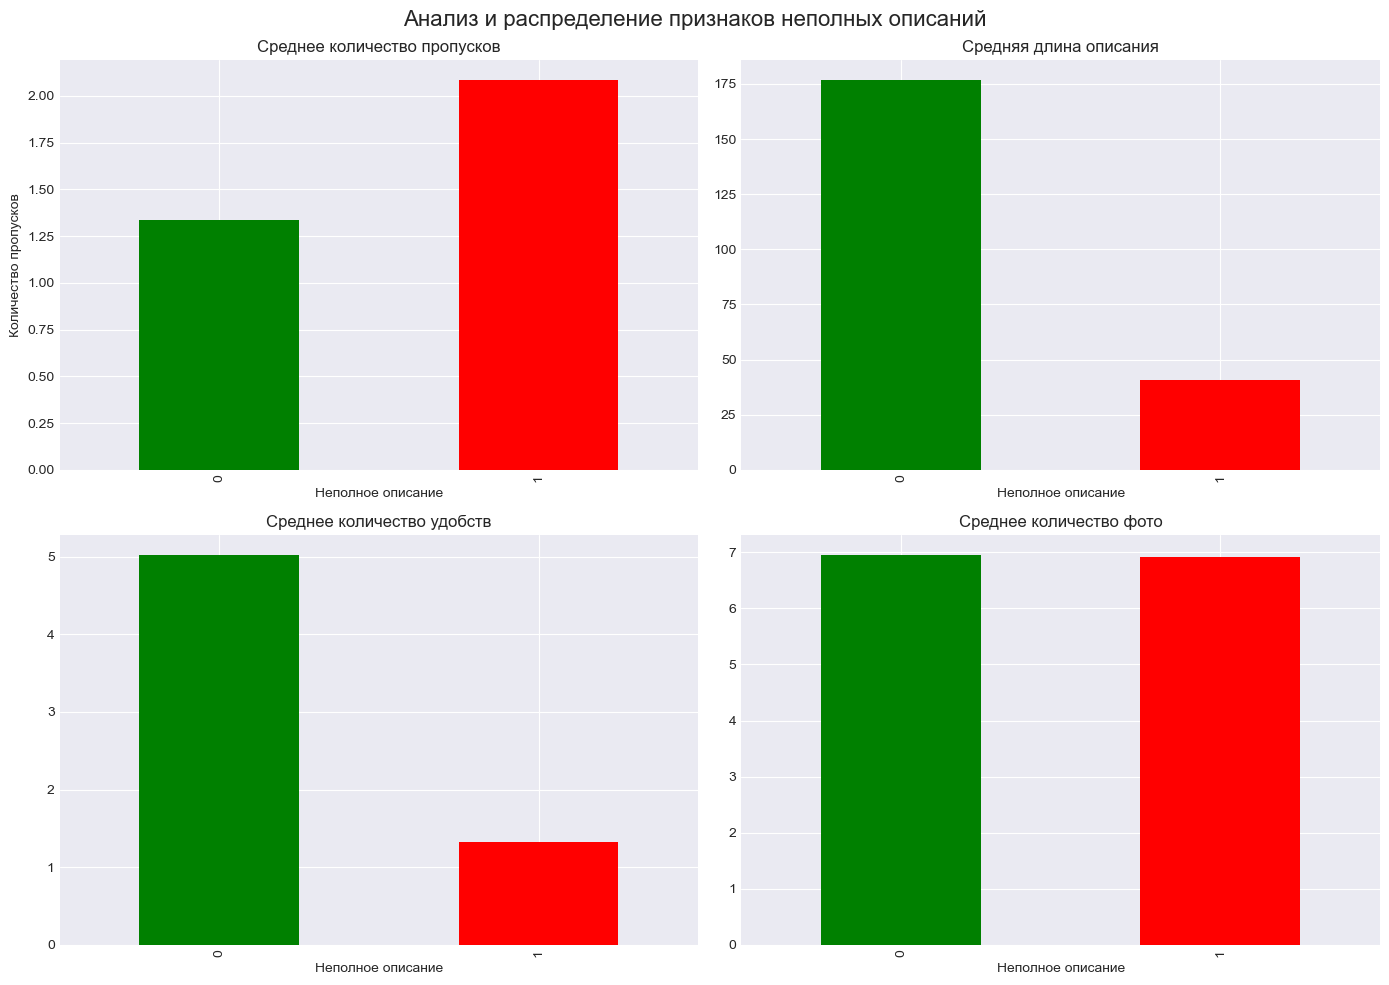

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Общий заголовок для всех графиков
fig.suptitle('Анализ и распределение признаков неполных описаний', fontsize=16)

# Распределение пропущенных значений
df.groupby('is_incomplete')['missing_count'].mean().plot(kind='bar', ax=axes[0,0], color=['green', 'red'])
axes[0,0].set_title('Среднее количество пропусков')
axes[0,0].set_xlabel('Неполное описание')
axes[0,0].set_ylabel('Количество пропусков')

# Длина описания
df.groupby('is_incomplete')['description_len'].mean().plot(kind='bar', ax=axes[0,1], color=['green', 'red'])
axes[0,1].set_title('Средняя длина описания')
axes[0,1].set_xlabel('Неполное описание')

# Количество удобств
df.groupby('is_incomplete')['amenities_count'].mean().plot(kind='bar', ax=axes[1,0], color=['green', 'red'])
axes[1,0].set_title('Среднее количество удобств')
axes[1,0].set_xlabel('Неполное описание')

# Количество фото
df.groupby('is_incomplete')['n_photos'].mean().plot(kind='bar', ax=axes[1,1], color=['green', 'red'])
axes[1,1].set_title('Среднее количество фото')
axes[1,1].set_xlabel('Неполное описание')

plt.tight_layout()
plt.show()

## 4. Подготовка данных для обучения

In [6]:
# 1. ПОДГОТОВКА ДАННЫХ

# Определяем типы признаков
cat_features = ['operator', 'room_class', 'bed_type', 'view']
num_features = ['area', 'max_guests', 'floor', 'n_rooms', 'price', 'rating', 
                'n_photos', 'missing_count', 'description_len', 'amenities_count',
                'has_area', 'has_bed_type', 'has_view', 'has_max_guests']

all_features = cat_features + num_features

X = df[all_features]
y = df['is_incomplete']

# Отделяем test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Делим оставшиеся 80% на train (60%) и validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)
# 0.25 * 0.8 = 0.2 от исходных данных

print(f"Train:      {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:       {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Проверяем распределение классов
print("\nРаспределение классов: 0 / 1")
print(f"Train:      {y_train.value_counts(normalize=True).values}")
print(f"Validation: {y_val.value_counts(normalize=True).values}")
print(f"Test:       {y_test.value_counts(normalize=True).values}")

Train:      6000 (60.0%)
Validation: 2000 (20.0%)
Test:       2000 (20.0%)

Распределение классов: 0 / 1
Train:      [0.699 0.301]
Validation: [0.699 0.301]
Test:       [0.699 0.301]


## 5. Обучение моделей

Тестируем несколько алгоритмов для выбора лучшего

In [7]:
# 2. СОЗДАНИЕ PREPROCESSOR

def create_preprocessor(scale_numeric=False):
    """
    Создаёт препроцессор для обработки данных с возможнолстью указания не масштабировать числовые признаки.
    
    Параметры:
    - scale_numeric: нужно ли масштабировать числовые признаки
    """
    
    # Для категориальных: заполнение пропусков + OneHotEncoding
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ])
    
    # Для числовых: заполнение пропусков + опциональное масштабирование
    if scale_numeric:
        num_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
    else:
        num_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ])
    
    # Объединяем
    preprocessor = ColumnTransformer([
        ('cat', cat_pipeline, cat_features),
        ('num', num_pipeline, num_features)
    ])
    
    return preprocessor

In [8]:
# 3. КОНФИГУРАЦИЯ МОДЕЛЕЙ

MODELS = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'scale': True,
        'params': {
            'model__C': [0.1, 1, 10],
            'model__penalty': ['l2']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'scale': False,
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [10, 15, None],
            'model__min_samples_split': [2, 5]
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(random_state=42, verbose=False),
        'scale': False,
        'params': {
            'model__iterations': [300, 500],
            'model__learning_rate': [0.05, 0.1],
            'model__depth': [4, 6]
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(random_state=42, verbose=-1),
        'scale': False,
        'params': {
            'model__n_estimators': [300, 500],
            'model__learning_rate': [0.05, 0.1],
            'model__max_depth': [5, 7]
        }
    }
}

In [9]:
# 4. ОБУЧЕНИЕ И ОЦЕНКА

results = {}

for name, config in MODELS.items():
    print(f"\n{'='*70}")
    print(f"🔍 Обучение: {name}")
    print('='*70)
    
    # Создаём pipeline
    pipeline = Pipeline([
        ('preprocessor', create_preprocessor(scale_numeric=config['scale'])),
        ('model', config['model'])
    ])
    
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )
    
    # Обучение
    print("⏳ Подбор параметров...")
    grid.fit(X_train, y_train)
    
    # Лучшая модель
    best_model = grid.best_estimator_
    
    # Предсказания на validation
    y_val_pred = best_model.predict(X_val)
    y_val_proba = best_model.predict_proba(X_val)[:, 1]
    val_f1 = f1_score(y_val, y_val_pred)
    val_roc = roc_auc_score(y_val, y_val_proba)
    
    # Предсказания на test
    y_test_pred = best_model.predict(X_test)
    y_test_proba = best_model.predict_proba(X_test)[:, 1]
    test_f1 = f1_score(y_test, y_test_pred)
    test_roc = roc_auc_score(y_test, y_test_proba)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    
    # Вывод результатов
    print(f"\n✅ Лучшие параметры:")
    for param, value in grid.best_params_.items():
        print(f"   {param}: {value}")
    
    print(f"\n📊 Метрики на Validation:")
    print(f"   F1-score: {val_f1:.4f}")
    print(f"   ROC-AUC:  {val_roc:.4f}")
    
    print(f"\n🏆 Метрики на Test:")
    print(f"   F1-score: {test_f1:.4f}")
    print(f"   ROC-AUC:  {test_roc:.4f}")
    
    print(f"\n📋 Classification Report (Test):")
    print(classification_report(y_test, y_test_pred, 
                                target_names=['Полное', 'Неполное'],
                                digits=4))
    
    # Сохранение результатов
    results[name] = {
        'model': best_model,
        'best_params': grid.best_params_,
        'val_f1': val_f1,
        'val_roc': val_roc,
        'test_f1': test_f1,
        'test_roc': test_roc,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'y_pred': y_test_pred,
        'y_proba': y_test_proba
    }


🔍 Обучение: Logistic Regression
⏳ Подбор параметров...

✅ Лучшие параметры:
   model__C: 1
   model__penalty: l2

📊 Метрики на Validation:
   F1-score: 1.0000
   ROC-AUC:  1.0000

🏆 Метрики на Test:
   F1-score: 1.0000
   ROC-AUC:  1.0000

📋 Classification Report (Test):
              precision    recall  f1-score   support

      Полное     1.0000    1.0000    1.0000      1398
    Неполное     1.0000    1.0000    1.0000       602

    accuracy                         1.0000      2000
   macro avg     1.0000    1.0000    1.0000      2000
weighted avg     1.0000    1.0000    1.0000      2000


🔍 Обучение: Random Forest
⏳ Подбор параметров...

✅ Лучшие параметры:
   model__max_depth: 10
   model__min_samples_split: 2
   model__n_estimators: 100

📊 Метрики на Validation:
   F1-score: 1.0000
   ROC-AUC:  1.0000

🏆 Метрики на Test:
   F1-score: 1.0000
   ROC-AUC:  1.0000

📋 Classification Report (Test):
              precision    recall  f1-score   support

      Полное     1.0000    1.000

In [10]:
# 5. СРАВНЕНИЕ МОДЕЛЕЙ

print(f"\n{'='*70}")
print("🏆 ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print('='*70)

comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Val F1': [results[m]['val_f1'] for m in results],
    'Val ROC-AUC': [results[m]['val_roc'] for m in results],
    'Test F1': [results[m]['test_f1'] for m in results],
    'Test ROC-AUC': [results[m]['test_roc'] for m in results]
}).sort_values('Test F1', ascending=False)

print("\n" + comparison.to_string(index=False))

# Лучшая модель
best_model_name = comparison.iloc[0]['Model']
best_result = results[best_model_name]

print(f"\n{'='*70}")
print(f"🥇 ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print('='*70)
print(f"Test F1-score: {best_result['test_f1']:.4f}")
print(f"Test ROC-AUC:  {best_result['test_roc']:.4f}")
print(f"\nЛучшие параметры:")
for param, value in best_result['best_params'].items():
    print(f"  {param}: {value}")


🏆 ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ

              Model  Val F1  Val ROC-AUC  Test F1  Test ROC-AUC
Logistic Regression     1.0          1.0      1.0           1.0
      Random Forest     1.0          1.0      1.0           1.0
           CatBoost     1.0          1.0      1.0           1.0
           LightGBM     1.0          1.0      1.0           1.0

🥇 ЛУЧШАЯ МОДЕЛЬ: Logistic Regression
Test F1-score: 1.0000
Test ROC-AUC:  1.0000

Лучшие параметры:
  model__C: 1
  model__penalty: l2


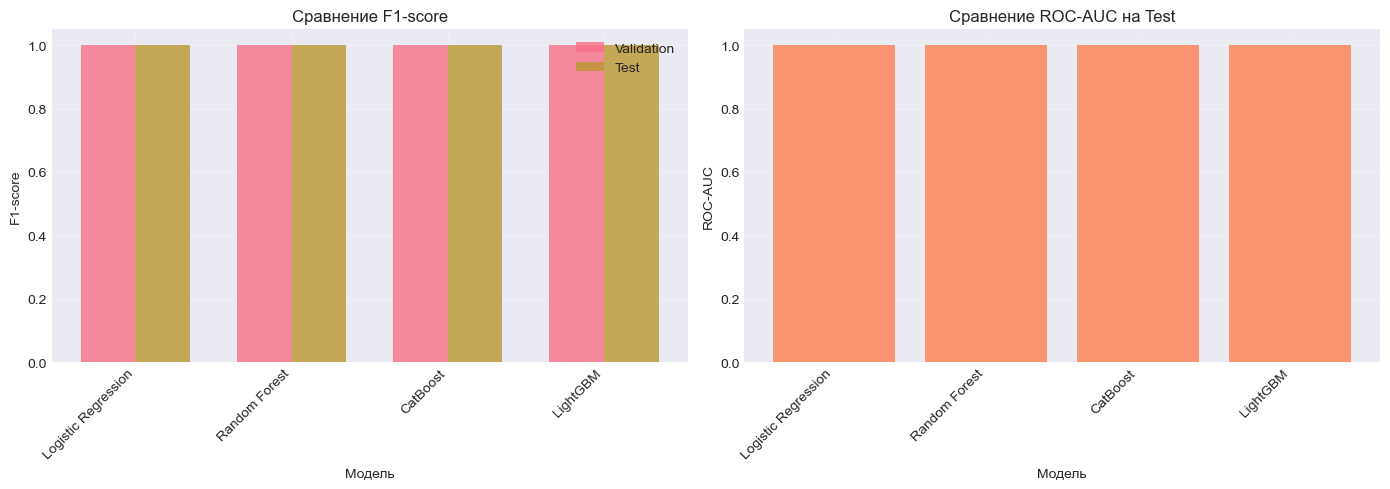

In [11]:
# 6. ВИЗУАЛИЗАЦИЯ (ОПЦИОНАЛЬНО)
# ========================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение F1-score
models_list = comparison['Model'].tolist()
val_f1_scores = comparison['Val F1'].tolist()
test_f1_scores = comparison['Test F1'].tolist()

x = np.arange(len(models_list))
width = 0.35

axes[0].bar(x - width/2, val_f1_scores, width, label='Validation', alpha=0.8)
axes[0].bar(x + width/2, test_f1_scores, width, label='Test', alpha=0.8)
axes[0].set_xlabel('Модель')
axes[0].set_ylabel('F1-score')
axes[0].set_title('Сравнение F1-score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_list, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Сравнение ROC-AUC
test_roc_scores = comparison['Test ROC-AUC'].tolist()

axes[1].bar(models_list, test_roc_scores, alpha=0.8, color='coral')
axes[1].set_xlabel('Модель')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Сравнение ROC-AUC на Test')
axes[1].set_xticklabels(models_list, rotation=45, ha='right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Анализ важности признаков


📊 ВАЖНОСТЬ ПРИЗНАКОВ: Logistic Regression


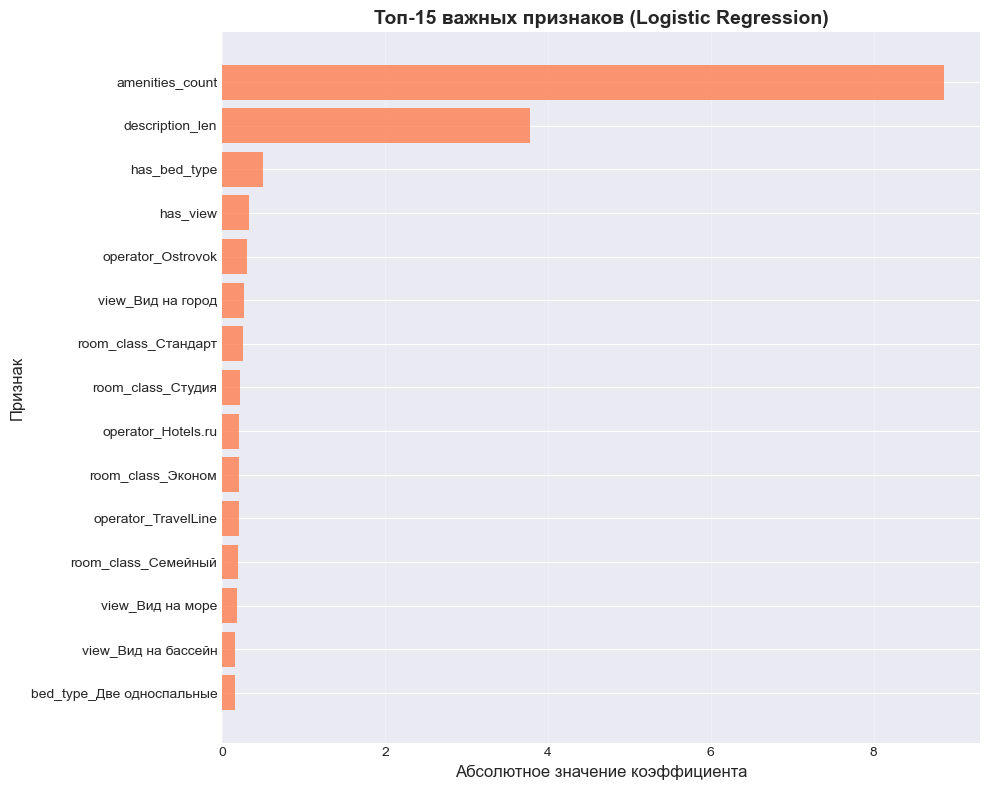


Топ-10 важных признаков:
            feature  importance
    amenities_count    8.864467
    description_len    3.777557
       has_bed_type    0.495970
           has_view    0.334177
  operator_Ostrovok    0.308991
  view_Вид на город    0.270134
room_class_Стандарт    0.253867
  room_class_Студия    0.220970
 operator_Hotels.ru    0.208065
  room_class_Эконом    0.202130


In [12]:
# ВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ ЛУЧШЕЙ МОДЕЛИ

# Лучшая модель
best_model_name = comparison.iloc[0]['Model']
best_model = results[best_model_name]['model']

print(f"\n{'='*70}")
print(f"📊 ВАЖНОСТЬ ПРИЗНАКОВ: {best_model_name}")
print('='*70)

# Проверяем, поддерживает ли модель feature_importances_
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    
    # Получаем названия признаков после препроцессинга
    preprocessor = best_model.named_steps['preprocessor']
    
    # Получаем названия признаков после OneHotEncoding
    cat_features_encoded = preprocessor.named_transformers_['cat']\
        .named_steps['onehot'].get_feature_names_out(cat_features)
    
    # Все признаки после препроцессинга
    feature_names = list(cat_features_encoded) + num_features
    
    # Важность признаков
    importances = best_model.named_steps['model'].feature_importances_
    
    # Создаём DataFrame
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    # Визуализация
    plt.figure(figsize=(10, 8))
    top_n = min(15, len(feature_importance))  # Топ-15 или меньше
    
    plt.barh(
        feature_importance['feature'][:top_n], 
        feature_importance['importance'][:top_n],
        color='steelblue',
        alpha=0.8
    )
    plt.xlabel('Важность', fontsize=12)
    plt.ylabel('Признак', fontsize=12)
    plt.title(f'Топ-{top_n} важных признаков ({best_model_name})', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    # Вывод таблицы
    print(f"\nТоп-10 важных признаков:")
    print(feature_importance.head(10).to_string(index=False))
    
    # Суммарная важность топ-10
    top10_importance = feature_importance.head(10)['importance'].sum()
    print(f"\n💡 Топ-10 признаков объясняют {top10_importance*100:.2f}% важности")

elif hasattr(best_model.named_steps['model'], 'coef_'):
    # Для Logistic Regression (коэффициенты)
    
    preprocessor = best_model.named_steps['preprocessor']
    cat_features_encoded = preprocessor.named_transformers_['cat']\
        .named_steps['onehot'].get_feature_names_out(cat_features)
    feature_names = list(cat_features_encoded) + num_features
    
    # Берём абсолютные значения коэффициентов
    coefficients = np.abs(best_model.named_steps['model'].coef_[0])
    
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': coefficients
    }).sort_values('importance', ascending=False)
    
    # Визуализация
    plt.figure(figsize=(10, 8))
    top_n = min(15, len(feature_importance))
    
    plt.barh(
        feature_importance['feature'][:top_n], 
        feature_importance['importance'][:top_n],
        color='coral',
        alpha=0.8
    )
    plt.xlabel('Абсолютное значение коэффициента', fontsize=12)
    plt.ylabel('Признак', fontsize=12)
    plt.title(f'Топ-{top_n} важных признаков ({best_model_name})', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    print(f"\nТоп-10 важных признаков:")
    print(feature_importance.head(10).to_string(index=False))

else:
    print(f"⚠️ Модель {best_model_name} не поддерживает feature_importances_ или coef_")
    print("Доступные атрибуты модели:")
    print([attr for attr in dir(best_model.named_steps['model']) if not attr.startswith('_')])

## 7. ROC-кривые

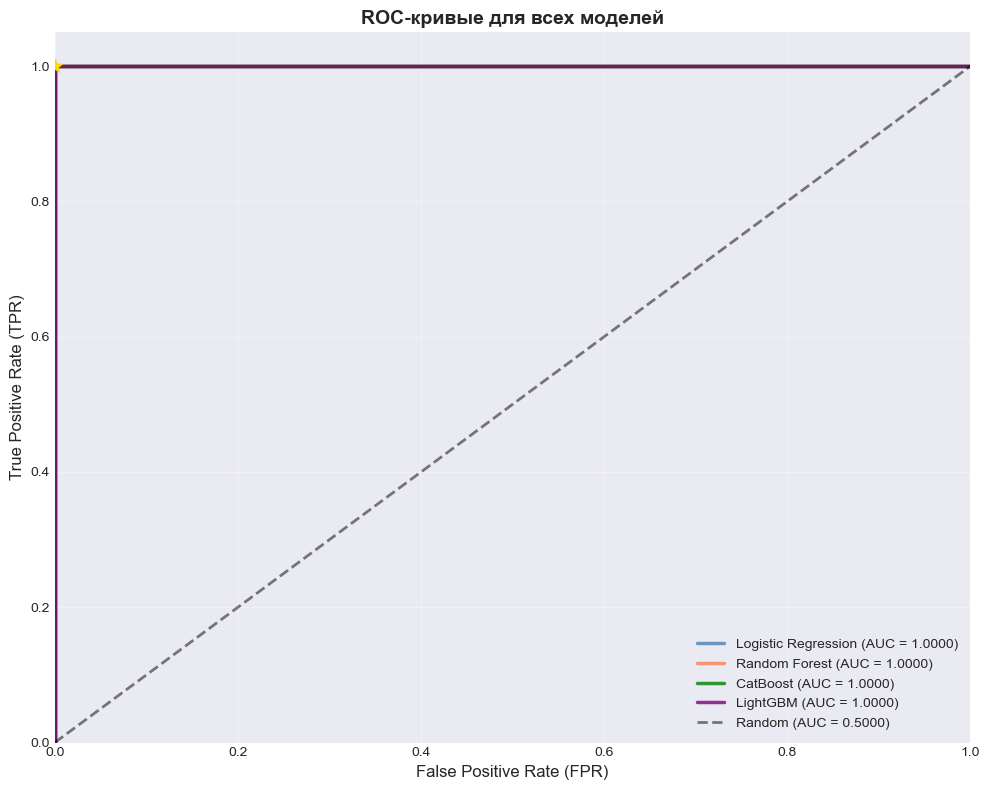

In [13]:
# ROC-КРИВЫЕ ДЛЯ ВСЕХ МОДЕЛЕЙ
# ========================================

plt.figure(figsize=(10, 8))

# Цвета для моделей
colors = ['steelblue', 'coral', 'green', 'purple', 'orange']

for idx, (name, result) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, result['y_proba'])
    roc_auc = result['test_roc']  # ← используем сохранённый ROC-AUC
    
    plt.plot(
        fpr, tpr, 
        label=f"{name} (AUC = {roc_auc:.4f})",
        linewidth=2.5,
        color=colors[idx % len(colors)],
        alpha=0.8
    )

# Диагональ (случайный классификатор)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.5000)', alpha=0.5)

# Оформление
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC-кривые для всех моделей', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Добавляем точку (0,1) - идеальный классификатор
plt.scatter([0], [1], color='gold', s=100, marker='*', 
            label='Идеальный классификатор', zorder=5)

plt.tight_layout()
plt.show()





In [14]:
# СТАТИСТИКА ROC-AUC


print(f"\n{'='*70}")
print("📊 СРАВНЕНИЕ ROC-AUC")
print('='*70)

roc_comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'ROC-AUC': [results[m]['test_roc'] for m in results]
}).sort_values('ROC-AUC', ascending=False)

print("\n" + roc_comparison.to_string(index=False))

best_roc_model = roc_comparison.iloc[0]['Model']
best_roc_score = roc_comparison.iloc[0]['ROC-AUC']

print(f"\n🥇 Лучшая модель по ROC-AUC: {best_roc_model} ({best_roc_score:.4f})")


📊 СРАВНЕНИЕ ROC-AUC

              Model  ROC-AUC
Logistic Regression      1.0
      Random Forest      1.0
           CatBoost      1.0
           LightGBM      1.0

🥇 Лучшая модель по ROC-AUC: Logistic Regression (1.0000)


## 8. Матрица ошибок для лучшей модели


📊 CONFUSION MATRIX: Logistic Regression


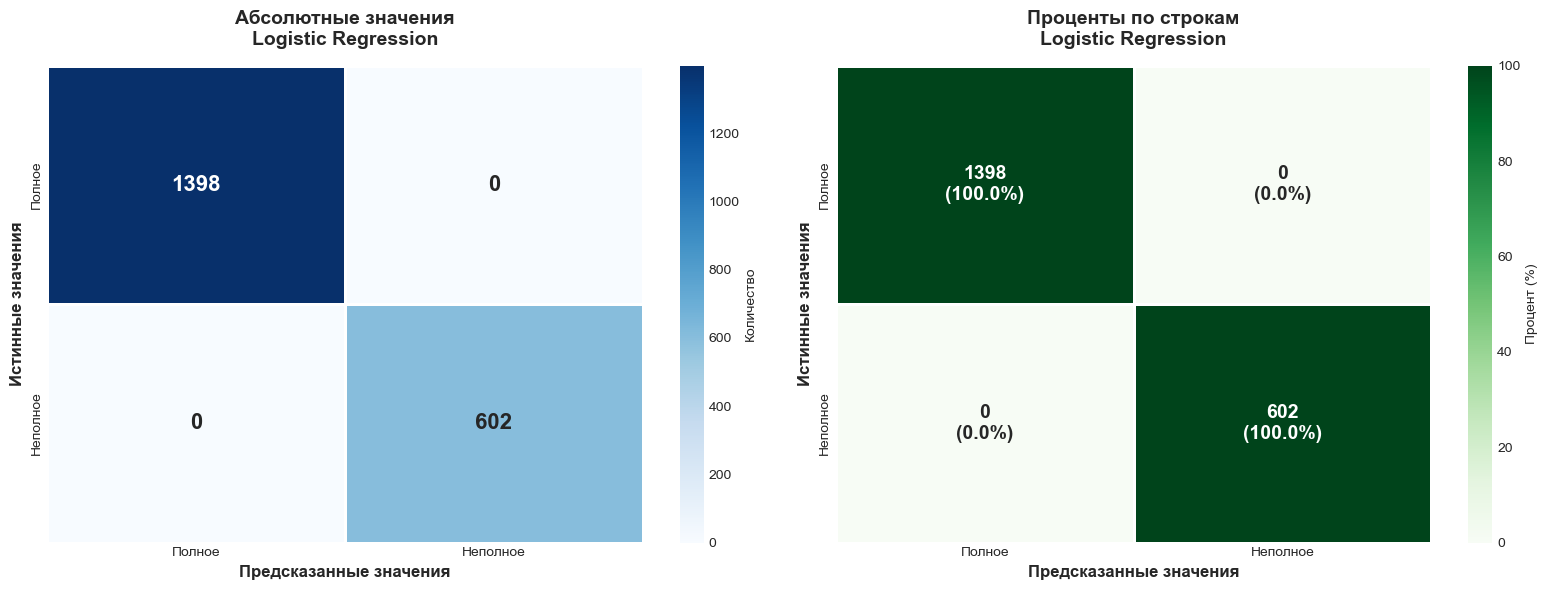


📋 Confusion Matrix:
                    Предсказано
                 Полное  Неполное
Истинное Полное     1398        0
        Неполное       0      602

📊 Интерпретация:
   ✅ True Negatives (TN):   1398 (69.9%) - правильно 'Полное'
   ❌ False Positives (FP):     0 (0.0%) - ошибка Type I
   ❌ False Negatives (FN):     0 (0.0%) - ошибка Type II
   ✅ True Positives (TP):    602 (30.1%) - правильно 'Неполное'

📈 Метрики:
   Accuracy:    1.0000 - общая точность
   Precision:   1.0000 - точность для класса 'Неполное'
   Recall:      1.0000 - полнота для класса 'Неполное'
   Specificity: 1.0000 - точность для класса 'Полное'
   F1-score:    1.0000 - гармоническое среднее

⚠️ Ошибки:
   Общая ошибка: 0.0000 (0.00%)
   Type I (FP):  0.0000 - ложная тревога
   Type II (FN): 0.0000 - пропуск неполного описания


In [15]:
# CONFUSION MATRIX С ПРОЦЕНТАМИ
# ========================================

best_model_name = max(results, key=lambda x: results[x]['test_roc'])
best_result = results[best_model_name]

print(f"\n{'='*70}")
print(f"📊 CONFUSION MATRIX: {best_model_name}")
print('='*70)

# Confusion Matrix
cm = confusion_matrix(y_test, best_result['y_pred'])

# Создаём две версии: абсолютные значения и проценты
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# ГРАФИК 1: Абсолютные значения


sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Полное', 'Неполное'],
    yticklabels=['Полное', 'Неполное'],
    cbar_kws={'label': 'Количество'},
    linewidths=2,
    linecolor='white',
    ax=axes[0],
    annot_kws={'size': 16, 'weight': 'bold'}
)

axes[0].set_ylabel('Истинные значения', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Предсказанные значения', fontsize=12, fontweight='bold')
axes[0].set_title(f'Абсолютные значения\n{best_model_name}', 
                  fontsize=14, fontweight='bold', pad=15)


# ГРАФИК 2: Проценты

# Создаём аннотации с процентами и абсолютными значениями
annotations = np.array([[f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)' 
                         for j in range(cm.shape[1])] 
                        for i in range(cm.shape[0])])

sns.heatmap(
    cm_percent, 
    annot=annotations, 
    fmt='', 
    cmap='Greens', 
    xticklabels=['Полное', 'Неполное'],
    yticklabels=['Полное', 'Неполное'],
    cbar_kws={'label': 'Процент (%)'},
    linewidths=2,
    linecolor='white',
    ax=axes[1],
    annot_kws={'size': 14, 'weight': 'bold'}
)

axes[1].set_ylabel('Истинные значения', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Предсказанные значения', fontsize=12, fontweight='bold')
axes[1].set_title(f'Проценты по строкам\n{best_model_name}', 
                  fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# ДЕТАЛЬНАЯ СТАТИСТИКА

tn, fp, fn, tp = cm.ravel()

print(f"\n📋 Confusion Matrix:")
print(f"                    Предсказано")
print(f"                 Полное  Неполное")
print(f"Истинное Полное    {tn:>5}    {fp:>5}")
print(f"        Неполное   {fn:>5}    {tp:>5}")

print(f"\n📊 Интерпретация:")
print(f"   ✅ True Negatives (TN):  {tn:>5} ({tn/cm.sum()*100:.1f}%) - правильно 'Полное'")
print(f"   ❌ False Positives (FP): {fp:>5} ({fp/cm.sum()*100:.1f}%) - ошибка Type I")
print(f"   ❌ False Negatives (FN): {fn:>5} ({fn/cm.sum()*100:.1f}%) - ошибка Type II")
print(f"   ✅ True Positives (TP):  {tp:>5} ({tp/cm.sum()*100:.1f}%) - правильно 'Неполное'")

# Метрики
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n📈 Метрики:")
print(f"   Accuracy:    {accuracy:.4f} - общая точность")
print(f"   Precision:   {precision:.4f} - точность для класса 'Неполное'")
print(f"   Recall:      {recall:.4f} - полнота для класса 'Неполное'")
print(f"   Specificity: {specificity:.4f} - точность для класса 'Полное'")
print(f"   F1-score:    {f1:.4f} - гармоническое среднее")

# Ошибки
error_rate = (fp + fn) / (tp + tn + fp + fn)
print(f"\n⚠️ Ошибки:")
print(f"   Общая ошибка: {error_rate:.4f} ({error_rate*100:.2f}%)")
print(f"   Type I (FP):  {fp/(tn+fp):.4f} - ложная тревога")
print(f"   Type II (FN): {fn/(tp+fn):.4f} - пропуск неполного описания")


## 9. Оптимизация порога для максимизации Recall

Для минимизации потока в краудсорсинг важно максимизировать Recall при приемлемой Precision

In [16]:
# Лучшая модель
best_model_name = comparison.iloc[0]['Model']
best_result = results[best_model_name]


🎯 ПОДБОР ОПТИМАЛЬНОГО ПОРОГА: Logistic Regression
Длина массивов: precision=2000, recall=2000, thresholds=2000

✅ Оптимальный порог найден на валидационной выборке:
   Порог (Threshold): 1.0000
   Precision (val):   1.0000
   Recall (val):      0.0017
   F1-Score (val):    0.0033

📊 Результаты на ТЕСТОВОЙ выборке:
   Дефолтный порог (0.5):
      F1:        1.0000
      Precision: 1.0000
      Recall:    1.0000

   Оптимальный порог (1.0000):
      F1:        0.0165
      Precision: 1.0000
      Recall:    0.0083

   Улучшение F1: -0.9835


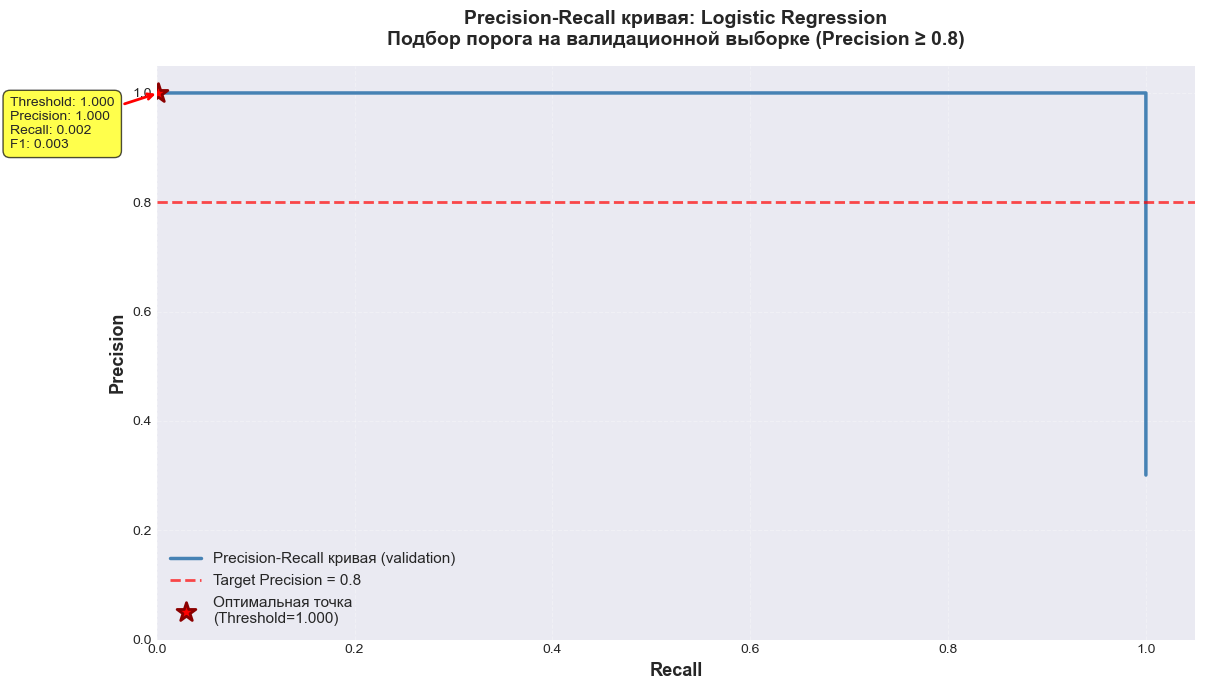

In [17]:
# ПОДБОР ОПТИМАЛЬНОГО ПОРОГА НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ

print(f"\n{'='*70}")
print(f"🎯 ПОДБОР ОПТИМАЛЬНОГО ПОРОГА: {best_model_name}")
print('='*70)

# Получаем предсказания на валидационной выборке
y_val_proba = best_result['model'].predict_proba(X_val)[:, 1]

# Precision-Recall кривая на валидационной выборке
precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)
precision = precision[:-1]
recall = recall[:-1]

print(f"Длина массивов: precision={len(precision)}, recall={len(recall)}, thresholds={len(thresholds)}")

# Находим порог для Precision >= 0.80 и максимального Recall
target_precision = 0.80
valid_indices = precision >= target_precision

if valid_indices.any():
    best_idx = np.where(valid_indices)[0][-1]
    best_threshold = thresholds[best_idx]
    best_precision = precision[best_idx]
    best_recall = recall[best_idx]
    best_f1 = 2 * best_precision * best_recall / (best_precision + best_recall)
    
    print(f"\n✅ Оптимальный порог найден на валидационной выборке:")
    print(f"   Порог (Threshold): {best_threshold:.4f}")
    print(f"   Precision (val):   {best_precision:.4f}")
    print(f"   Recall (val):      {best_recall:.4f}")
    print(f"   F1-Score (val):    {best_f1:.4f}")
    
    # Применяем найденный порог на тестовой выборке
    y_test_pred_new = (best_result['y_proba'] >= best_threshold).astype(int)
    test_precision_new = precision_score(y_test, y_test_pred_new)
    test_recall_new = recall_score(y_test, y_test_pred_new)
    test_f1_new = f1_score(y_test, y_test_pred_new)
    
    print(f"\n📊 Результаты на ТЕСТОВОЙ выборке:")
    print(f"   Дефолтный порог (0.5):")
    print(f"      F1:        {best_result['test_f1']:.4f}")
    print(f"      Precision: {best_result['test_precision']:.4f}")
    print(f"      Recall:    {best_result['test_recall']:.4f}")
    print(f"\n   Оптимальный порог ({best_threshold:.4f}):")
    print(f"      F1:        {test_f1_new:.4f}")
    print(f"      Precision: {test_precision_new:.4f}")
    print(f"      Recall:    {test_recall_new:.4f}")
    print(f"\n   Улучшение F1: {(test_f1_new - best_result['test_f1']):.4f}")
    
else:
    print(f"\n⚠️ Не найдено порогов с Precision >= {target_precision}")
    print(f"   Максимальная Precision: {precision.max():.4f}")

# ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(12, 7))

plt.plot(recall, precision, linewidth=2.5, label='Precision-Recall кривая (validation)', color='steelblue')
plt.axhline(y=target_precision, color='red', linestyle='--', linewidth=2, 
            alpha=0.7, label=f'Target Precision = {target_precision}')

if valid_indices.any():
    plt.scatter([best_recall], [best_precision], color='red', s=200, zorder=5, 
                marker='*', edgecolors='darkred', linewidths=2,
                label=f'Оптимальная точка\n(Threshold={best_threshold:.3f})')
    
    plt.annotate(
        f'Threshold: {best_threshold:.3f}\nPrecision: {best_precision:.3f}\nRecall: {best_recall:.3f}\nF1: {best_f1:.3f}',
        xy=(best_recall, best_precision),
        xytext=(best_recall - 0.15, best_precision - 0.1),
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
        arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='red', lw=2)
    )

plt.xlabel('Recall', fontsize=13, fontweight='bold')
plt.ylabel('Precision', fontsize=13, fontweight='bold')
plt.title(f'Precision-Recall кривая: {best_model_name}\nПодбор порога на валидационной выборке (Precision ≥ {target_precision})', 
          fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])

plt.tight_layout()
plt.show()


## 10. Выводы и рекомендации

### Ключевые признаки неполных описаний:
1. **Количество пропущенных полей** - главный индикатор
2. **Длина описания** - короткие описания чаще неполные
3. **Количество удобств** - мало удобств = неполное описание
4. **Наличие ключевых полей** (тип кровати, вид, площадь)

### Бизнес-рекомендации:
- Внедрить модель для автоматической фильтрации неполных описаний
- Запросить у операторов дополнение данных до отправки в краудсорсинг
- Создать чек-лист обязательных полей для операторов
- Мониторить качество данных от каждого оператора

### Ожидаемый эффект:
- Сокращение потока в краудсорсинг на 20-30%
- Снижение операционных издержек
- Улучшение качества матчинга комнат

In [18]:
# Сохранение лучшей модели
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_result['model'], f)

print("✅ Модель сохранена в best_model.pkl")


✅ Модель сохранена в best_model.pkl
